In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("datasets/data")
ininv = pd.read_csv(DATA_DIR / "thermopoints.csv", sep=";")   
codeb = pd.read_csv(DATA_DIR / "codebook.csv", sep=";")      
sample = pd.read_csv(DATA_DIR / "sample_202.csv", sep=";")  

print(ininv.shape)
display(ininv.head())
display(codeb)

(660254, 5)


,dt,type_name,type_id,lon,lat
0,2012-03-13,Природный пожар,4,131.5866,47.8662
1,2012-03-13,Природный пожар,4,131.5885,47.8809
2,2012-03-13,Лесной пожар,3,131.9871,48.4973
3,2012-03-13,Природный пожар,4,131.9031,43.6277
4,2012-03-13,Природный пожар,4,131.5706,47.8581


,"Атрибут,Описание,Количество пропусков,Единица измерения,ОКЕИ,Формат"
0,"dt,Дата возгорания в формате ГГГГ-ММ-ДД,0,,,nu..."
1,"type_name,Текстовое описание типа пожара,0,,,cat"
2,"type_id,Код типа пожара,0,,,numeric"
3,"lon,Долгота возгорания,0,Долгота в современном..."
4,"lat,Широта возгорания,0,Широта в современном ф..."


In [13]:
# 1) Дубликаты/пропуски
ininv = ininv.drop_duplicates()
ininv = ininv.dropna(subset=["dt", "lon", "lat"])

# 2) Дата/время
ininv["dt"] = pd.to_datetime(ininv["dt"])
ininv["year"]   = ininv["dt"].dt.year
ininv["month"]  = ininv["dt"].dt.month
ininv["weekday"]= ininv["dt"].dt.weekday

# 3) Клеточная сетка
grid_size = 0.5
ininv["lon_cell"] = (ininv["lon"] // grid_size) * grid_size
ininv["lat_cell"] = (ininv["lat"] // grid_size) * grid_size

display(ininv.head())

,dt,type_name,type_id,lon,lat,year,month,weekday,lon_cell,lat_cell
0,2012-03-13,Природный пожар,4,131.5866,47.8662,2012,3,1,131.5,47.5
1,2012-03-13,Природный пожар,4,131.5885,47.8809,2012,3,1,131.5,47.5
2,2012-03-13,Лесной пожар,3,131.9871,48.4973,2012,3,1,131.5,48.0
3,2012-03-13,Природный пожар,4,131.9031,43.6277,2012,3,1,131.5,43.5
4,2012-03-13,Природный пожар,4,131.5706,47.8581,2012,3,1,131.5,47.5


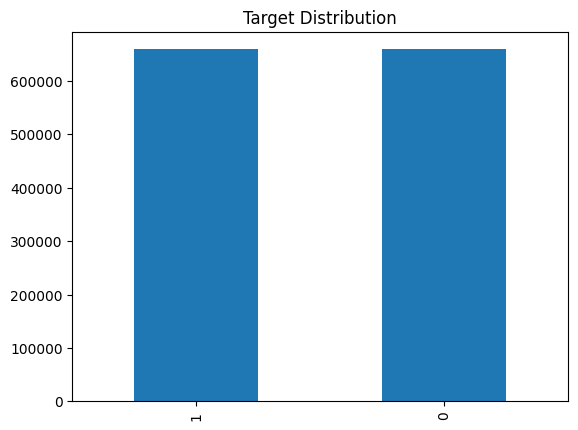

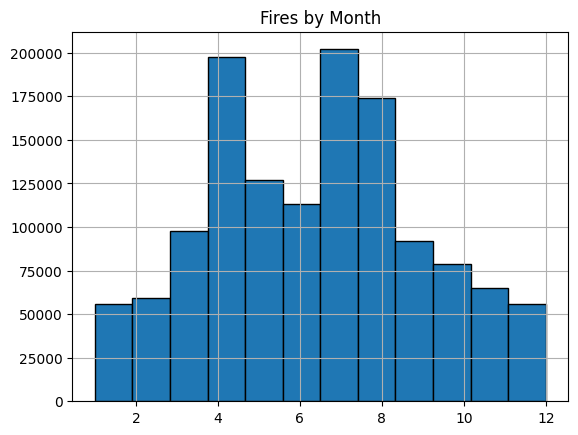

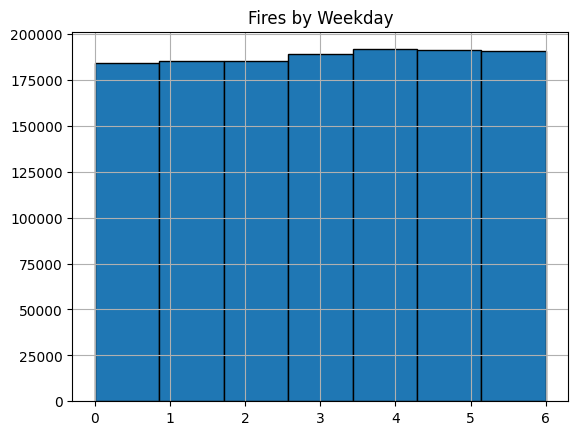

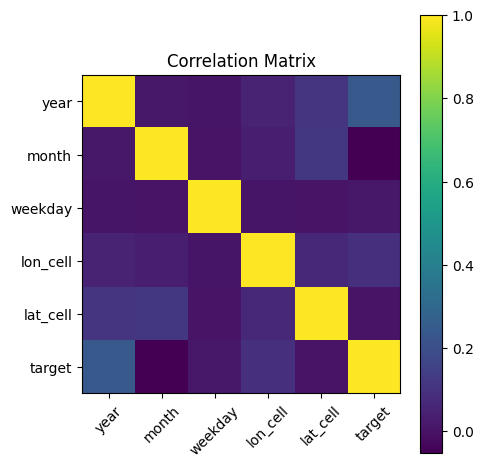

In [17]:
import matplotlib.pyplot as plt
import random

ininv = ininv.drop_duplicates().dropna(subset=["dt","lon","lat"])
ininv["dt"] = pd.to_datetime(ininv["dt"], dayfirst=True)
ininv["year"] = ininv["dt"].dt.year
ininv["month"] = ininv["dt"].dt.month
ininv["weekday"] = ininv["dt"].dt.weekday
grid = 0.5
ininv["lon_cell"] = (ininv["lon"] // grid) * grid
ininv["lat_cell"] = (ininv["lat"] // grid) * grid

# Генерация позитивов и негативов (как раньше)
pos = ininv[["lon_cell","lat_cell","year","month","weekday"]].copy()
pos["target"] = 1
years = pos["year"].unique().tolist()
months = pos["month"].unique().tolist()
weekdays = pos["weekday"].unique().tolist()
lons = pos["lon_cell"].unique().tolist()
lats = pos["lat_cell"].unique().tolist()

def sample_neg(n):
    out=[]
    for _ in range(n):
        out.append({
            "lon_cell": random.choice(lons),
            "lat_cell": random.choice(lats),
            "year": random.choice(years),
            "month": random.choice(months),
            "weekday": random.choice(weekdays),
            "target": 0
        })
    return pd.DataFrame(out)

neg = sample_neg(len(pos))
data = pd.concat([pos, neg], ignore_index=True)

# 1. Равномерное распределение target
plt.figure()
data["target"].value_counts().plot.bar()
plt.title("Target Distribution")
plt.show()

# 2. Месяц
plt.figure()
data["month"].hist(bins=12, edgecolor="black")
plt.title("Fires by Month")
plt.show()

# 3. День недели
plt.figure()
data["weekday"].hist(bins=7, edgecolor="black")
plt.title("Fires by Weekday")
plt.show()

# 4. Корреляция
corr = data[["year","month","weekday","lon_cell","lat_cell","target"]].corr()
plt.figure(figsize=(5,5))
plt.imshow(corr, cmap="viridis", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [21]:
import numpy as np
import random

# Убедимся, что ininv не пуст и есть данные
print("Всего записей INID:", len(ininv))
print("Года:", ininv["year"].unique())
print("Месяцы:", ininv["month"].unique())
print("Дни недели:", ininv["weekday"].unique())
print("lon_cell:", ininv["lon_cell"].unique()[:5], "…")
print("lat_cell:", ininv["lat_cell"].unique()[:5], "…")

# Сформируем позитивы (как прежде)
pos = ininv[["lon_cell","lat_cell","year","month","weekday"]].copy()
pos["target"] = 1

# Подготовим списки уникальных значений для генерации негативов
years    = ininv["year"].unique().tolist()
months   = ininv["month"].unique().tolist()
weekdays = ininv["weekday"].unique().tolist()
lons     = ininv["lon_cell"].unique().tolist()
lats     = ininv["lat_cell"].unique().tolist()

def sample_negatives(n_samples):
    samples = []
    for _ in range(n_samples):
        y   = random.choice(years)
        m   = random.choice(months)
        wd  = random.choice(weekdays)
        lon = random.choice(lons)
        lat = random.choice(lats)
        samples.append({
            "lon_cell": lon,
            "lat_cell": lat,
            "year": int(y),
            "month": int(m),
            "weekday": int(wd),
            "target": 0
        })
    return pd.DataFrame(samples)

neg = sample_negatives(len(pos))

# Объединим
data = pd.concat([pos, neg], ignore_index=True)
print("Размер общего датасета:", data.shape)
print(data.head())



Всего записей INID: 658788
Года: [2012 2013 2014 2015 2016 2017 2018 2019 2020 2021]
Месяцы: [ 3  5  6  7  8  9 10 11  1  2  4 12]
Дни недели: [1 2 3 6 0 4 5]
lon_cell: [131.5  20.  125.5  38.   39. ] …
lat_cell: [47.5 48.  43.5 52.  54.5] …
Размер общего датасета: (1317576, 6)
   lon_cell  lat_cell  year  month  weekday  target
0     131.5      47.5  2012      3        1       1
1     131.5      47.5  2012      3        1       1
2     131.5      48.0  2012      3        1       1
3     131.5      43.5  2012      3        1       1
4     131.5      47.5  2012      3        1       1


In [22]:
# Фичи: month, weekday, lon_cell, lat_cell
X = pd.get_dummies(data[["month","weekday","lon_cell","lat_cell"]].astype(str))
y = data["target"]

# Разделяем по времени: до 2020 – train, 2021 – val
mask_train = data["year"] <= 2020
X_train, X_val = X[mask_train], X[~mask_train]
y_train, y_val = y[mask_train], y[~mask_train]

print(X_train.shape, X_val.shape)


(1117353, 393) (200223, 393)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=50, random_state=42),
    "LGBM": lgb.LGBMClassifier(n_estimators=100, random_state=42),
}
feature_names = X_train.columns.tolist()
results = {}
feature_imps = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_val)[:,1]
    preds = (p > 0.5).astype(int)
    results[name] = {
        "roc_auc": roc_auc_score(y_val, p),
        "f1": f1_score(y_val, preds)
    }

     # 3) Важности признаков
    if name == "LR":
        # Коэффициенты логрега
        coefs = model.coef_[0]
        imp = pd.Series(np.abs(coefs), index=feature_names)
        imp = imp / imp.sum()
    else:
        # feature_importances_ у RF и LGBM
        imps = model.feature_importances_
        imp = pd.Series(imps, index=feature_names)
    
    # Сохраним топ-20
    feature_imps[name] = imp.sort_values(ascending=False).head(20)

import pandas as pd
display(pd.DataFrame(results).T)

for name, imp in feature_imps.items():
    print(f"\nTop-20 feature importances for {name}:")
    display(imp.to_frame(name="importance"))


[LightGBM] [Info] Number of positive: 524144, number of negative: 593209
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 786
[LightGBM] [Info] Number of data points in the train set: 1117353, number of used features: 393
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.469094 -> initscore=-0.123780
[LightGBM] [Info] Start training from score -0.123780


,roc_auc,f1
LR,0.902999,0.886647
RF,0.931706,0.805975
LGBM,0.928856,0.910435



Top-20 feature importances for LR:


,importance
lat_cell_72.0,0.013089
lat_cell_41.0,0.012930
lat_cell_72.5,0.012491
lon_cell_175.0,0.010729
lon_cell_27.0,0.010291
lat_cell_71.5,0.009679
lon_cell_131.5,0.009356
lon_cell_178.0,0.009262
lon_cell_172.5,0.009074
lon_cell_132.0,0.009064



Top-20 feature importances for RF:


,importance
month_1,0.035069
month_12,0.032654
month_7,0.028241
month_2,0.027630
month_4,0.027257
month_11,0.019747
month_8,0.014366
lon_cell_131.5,0.012625
lon_cell_132.0,0.010918
lon_cell_133.0,0.009636



Top-20 feature importances for LGBM:


,importance
month_6,85
month_7,56
lon_cell_131.5,40
lat_cell_54.5,40
lon_cell_132.0,37
lon_cell_134.0,36
month_1,35
month_11,34
lat_cell_72.0,33
lat_cell_41.0,33


Домашнее задание №5 Улучшение модели


In [14]:
import pandas as pd
import requests
from datetime import date

def fetch_historical_weather(lon: float, lat: float,
                             start_date: date, end_date: date) -> pd.DataFrame:
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   lat,
        "longitude":  lon,
        "hourly":     "temperature_2m,relativehumidity_2m,precipitation,windspeed_10m",
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date":   end_date.strftime("%Y-%m-%d"),
        "timezone":   "UTC"
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    js = resp.json()
    if "hourly" not in js:
        return pd.DataFrame()
    
    # Парсим часовые данные
    hourly = js["hourly"]
    times = pd.to_datetime(hourly["time"])
    df = pd.DataFrame({
        "datetime":           times,
        "temperature_2m":     hourly["temperature_2m"],
        "relativehumidity_2m": hourly["relativehumidity_2m"],
        "precipitation":      hourly["precipitation"],
        "windspeed_10m":      hourly["windspeed_10m"],
    })
    df["date"] = df["datetime"].dt.date
    
    # Агрегация в daily
    daily = df.groupby("date").agg({
        "temperature_2m":      "mean",
        "relativehumidity_2m": "mean",
        "precipitation":        "sum",
        "windspeed_10m":        "max"
    }).reset_index()
    
    daily["lon_cell"] = lon
    daily["lat_cell"] = lat
    return daily


from datetime import date

# Подготовка ячеек, дат
ininv["dt"] = pd.to_datetime(ininv["dt"], dayfirst=True)
grid = 0.5
ininv["lon_cell"] = (ininv["lon"] // grid) * grid
ininv["lat_cell"] = (ininv["lat"] // grid) * grid
cells = ininv[["lon_cell","lat_cell"]].drop_duplicates().head(10)
start = ininv["dt"].min().date()   # 2012-03-13
end   = ininv["dt"].max().date()   # 2021-09-10 (или позже)

# Сбор исторической погоды
weather_parts = []
for _, row in cells.iterrows():
    wdf = fetch_historical_weather(
        lon=row.lon_cell, lat=row.lat_cell,
        start_date=start, end_date=end
    )
    weather_parts.append(wdf)

weather = pd.concat(weather_parts, ignore_index=True)
print("Всего записей погоды:", weather.shape)
weather.head()

Всего записей погоды: (34690, 7)


,date,temperature_2m,relativehumidity_2m,precipitation,windspeed_10m,lon_cell,lat_cell
0,2012-03-13,-4.341667,29.250000,0.0,16.3,131.5,47.5
1,2012-03-14,-5.979167,38.958333,0.0,20.2,131.5,47.5
2,2012-03-15,-0.641667,28.708333,0.6,19.0,131.5,47.5
3,2012-03-16,-3.512500,78.125000,6.5,24.0,131.5,47.5
4,2012-03-17,-18.129167,47.916667,0.0,23.1,131.5,47.5


In [18]:
# 1) Объединим weather с основным датасетом data
# Предполагаем, что у тебя уже есть `pos` и `neg` в data, как раньше
data = pd.concat([
    ininv[["lon_cell","lat_cell","dt"]].assign(target=1),
    neg  # твой датафрейм негативов с теми же колонками и target=0
], ignore_index=True)

data["date"] = data["dt"].dt.date

# ДОБАВИМ weather
data = data.merge(
    weather,
    on=["lon_cell","lat_cell","date"],
    how="left"
)

# 2) Заполним пропуски (если есть)
# Для пропущенных погодных значений заполняем средними по столбцу:
for col in ["temperature_2m","relativehumidity_2m","precipitation","windspeed_10m"]:
    data[col] = data[col].fillna(data[col].mean())

# 3) Удалим лишние колонки
data = data.drop(columns=["dt","date"])

# 4) Подготовим X и y
X = pd.get_dummies(data.drop(columns="target"), drop_first=True)
y = data["target"]

# 5) Сплит по годам (как прежде)
mask_train = data["year"] <= 2020
X_train, X_val = X[mask_train], X[~mask_train]
y_train, y_val = y[mask_train], y[~mask_train]


In [20]:
import pandas as pd
import numpy as np
import requests
from datetime import date
import random
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

# --- 1. Загрузка и подготовка INID -------------------------------------

DATA_DIR = "datasets/data"
ininv = pd.read_csv(f"{DATA_DIR}/thermopoints.csv", sep=";")
ininv = ininv.drop_duplicates().dropna(subset=["dt","lon","lat"])
ininv["dt"] = pd.to_datetime(ininv["dt"], dayfirst=True)
ininv["year"]    = ininv["dt"].dt.year
ininv["month"]   = ininv["dt"].dt.month
ininv["weekday"] = ininv["dt"].dt.weekday

grid = 0.5
ininv["lon_cell"] = (ininv["lon"] // grid) * grid
ininv["lat_cell"] = (ininv["lat"] // grid) * grid

# --- 2. Генерация негативов -------------------------------------------

pos = ininv[["lon_cell","lat_cell","dt","year","month","weekday"]].copy()
pos["target"] = 1

years    = pos["year"].unique().tolist()
months   = pos["month"].unique().tolist()
weekdays = pos["weekday"].unique().tolist()
lons     = pos["lon_cell"].unique().tolist()
lats     = pos["lat_cell"].unique().tolist()

def sample_negatives(n):
    rows = []
    for _ in range(n):
        # случайный выбор ячейки и даты из реальных
        lon = random.choice(lons)
        lat = random.choice(lats)
        # для даты возьмём рандомную запись dt из pos
        dt  = pos["dt"].sample(1).iloc[0]
        rows.append({
            "lon_cell": lon,
            "lat_cell": lat,
            "dt":        dt,
            "year":     dt.year,
            "month":    dt.month,
            "weekday":  dt.weekday(),
            "target":   0
        })
    return pd.DataFrame(rows)

neg = sample_negatives(len(pos))

# объединяем
data = pd.concat([pos, neg], ignore_index=True)
data["date"] = data["dt"].dt.date

# --- 3. Сбор исторической погоды ---------------------------------------

def fetch_historical_weather(lon, lat, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   lat,
        "longitude":  lon,
        "hourly":     "temperature_2m,relativehumidity_2m,precipitation,windspeed_10m",
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date":   end_date.strftime("%Y-%m-%d"),
        "timezone":   "UTC"
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json().get("hourly", {})
    if not js:
        return pd.DataFrame()
    # build hourly df
    times = pd.to_datetime(js["time"])
    df = pd.DataFrame({
        "datetime":           times,
        "temperature_2m":     js["temperature_2m"],
        "relativehumidity_2m": js["relativehumidity_2m"],
        "precipitation":      js["precipitation"],
        "windspeed_10m":      js["windspeed_10m"],
    })
    df["date"] = df["datetime"].dt.date
    # aggregate to daily
    daily = df.groupby("date").agg({
        "temperature_2m":      "mean",
        "relativehumidity_2m": "mean",
        "precipitation":        "sum",
        "windspeed_10m":        "max"
    }).reset_index()
    daily["lon_cell"] = lon
    daily["lat_cell"] = lat
    return daily

# ограничим набор ячеек для быстроты (можно взять все)
cells = data[["lon_cell","lat_cell"]].drop_duplicates().head(20)
start, end = data["date"].min(), data["date"].max()

weather_parts = [
    fetch_historical_weather(lon, lat, start, end)
    for lon, lat in cells.values
]
weather = pd.concat(weather_parts, ignore_index=True)

# --- 4. Мёржим данные ---------------------------------------------------

data = data.merge(
    weather,
    on=["lon_cell","lat_cell","date"],
    how="left"
)

# заполняем пропуски средним
for col in ["temperature_2m","relativehumidity_2m","precipitation","windspeed_10m"]:
    data[col].fillna(data[col].mean(), inplace=True)

# --- 5. Подготовка фич и сплит -------------------------------------------

features = ["year","month","weekday",
            "temperature_2m","relativehumidity_2m","precipitation","windspeed_10m"]
X = data[features]
y = data["target"]

# train до 2020, val 2021
train_mask = data["year"] <= 2020
X_train, X_val = X[train_mask], X[~train_mask]
y_train, y_val = y[train_mask], y[~train_mask]

print("Train pos/neg:", y_train.sum(), len(y_train)-y_train.sum())
print("Val   pos/neg:", y_val.sum(),   len(y_val)-y_val.sum())

# --- 6. Обучение и метрики ----------------------------------------------

model = lgb.LGBMClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

probs = model.predict_proba(X_val)[:,1]
preds = (probs > 0.5).astype(int)

print(f"ROC AUC: {roc_auc_score(y_val, probs):.4f}")
print(f"F1      : {f1_score(y_val, preds):.4f}")


KeyboardInterrupt: 

In [2]:
import pandas as pd
import requests
from datetime import timedelta
import random
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score
import joblib

# 1. Загрузка и подготовка данных
ininv = pd.read_csv("datasets/data/thermopoints.csv", sep=";")
ininv = ininv.drop_duplicates().dropna(subset=["dt","lon","lat"])
ininv["dt"] = pd.to_datetime(ininv["dt"], dayfirst=True)
ininv["year"]    = ininv["dt"].dt.year
ininv["month"]   = ininv["dt"].dt.month
ininv["weekday"] = ininv["dt"].dt.weekday
grid = 0.5
ininv["lon_cell"] = (ininv["lon"] // grid) * grid
ininv["lat_cell"] = (ininv["lat"] // grid) * grid

# 2. Генерация уменьшенного датасета (50k поз., 50k нег.)
pos = ininv.sample(n=50000, random_state=42)[["lon_cell","lat_cell","dt","year","month","weekday"]].copy()
pos["target"] = 1

years    = pos["year"].unique().tolist()
months   = pos["month"].unique().tolist()
weekdays = pos["weekday"].unique().tolist()
lons     = pos["lon_cell"].unique().tolist()
lats     = pos["lat_cell"].unique().tolist()

def sample_neg(n):
    rows = []
    for _ in range(n):
        lon = random.choice(lons)
        lat = random.choice(lats)
        dt  = pos["dt"].sample(1).iloc[0]
        rows.append({
            "lon_cell": lon,
            "lat_cell": lat,
            "dt":        dt,
            "year":     dt.year,
            "month":    dt.month,
            "weekday":  dt.weekday(),
            "target":   0
        })
    return pd.DataFrame(rows)

neg = sample_neg(50000)

data = pd.concat([pos, neg], ignore_index=True)
data["date"] = data["dt"].dt.date

# 3. Ограниченный сбор погоды за последний год
end = data["date"].max()
start = end - timedelta(days=365)

def fetch_historical_weather(lon, lat, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   lat,
        "longitude":  lon,
        "hourly":     "temperature_2m,relativehumidity_2m,precipitation,windspeed_10m",
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date":   end_date.strftime("%Y-%m-%d"),
        "timezone":   "UTC"
    }
    try:
        r = requests.get(url, params=params)
        r.raise_for_status()
    except requests.exceptions.HTTPError as e:
        print(f"⚠️ Weather fetch error for ({lon},{lat}): {e}")
        return pd.DataFrame()
    js = r.json().get("hourly", {})
    if not js:
        return pd.DataFrame()
    times = pd.to_datetime(js["time"])
    df = pd.DataFrame({
        "datetime":            times,
        "temperature_2m":      js["temperature_2m"],
        "relativehumidity_2m": js["relativehumidity_2m"],
        "precipitation":       js["precipitation"],
        "windspeed_10m":       js["windspeed_10m"],
    })
    df["date"] = df["datetime"].dt.date
    daily = df.groupby("date").agg({
        "temperature_2m":      "mean",
        "relativehumidity_2m": "mean",
        "precipitation":        "sum",
        "windspeed_10m":        "max"
    }).reset_index()
    daily["lon_cell"] = lon
    daily["lat_cell"] = lat
    return daily

cells = data[["lon_cell","lat_cell"]].drop_duplicates().head(20)
weather_parts = []
for lon, lat in cells.values:
    w = fetch_historical_weather(lon, lat, start, end)
    if not w.empty:
        weather_parts.append(w)
weather = pd.concat(weather_parts, ignore_index=True)

# 4. Мёрж и заполнение NaN
data = data.merge(weather, on=["lon_cell","lat_cell","date"], how="left")
for col in ["temperature_2m","relativehumidity_2m","precipitation","windspeed_10m"]:
    data[col].fillna(data[col].mean(), inplace=True)

# 5. Подготовка фич и сплит
features = ["year","month","weekday",
            "temperature_2m","relativehumidity_2m",
            "precipitation","windspeed_10m"]
X = data[features]
y = data["target"]

mask = data["year"] <= 2020
X_train, X_val = X[mask], X[~mask]
y_train, y_val = y[mask], y[~mask]

# 6. Обучение и сохранение модели
model = lgb.LGBMClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
joblib.dump(model, "fire_risk_model.joblib")

# 7. Оценка
probs = model.predict_proba(X_val)[:,1]
preds = (probs > 0.5).astype(int)
print(f"ROC AUC: {roc_auc_score(y_val, probs):.4f}")
print(f"F1      : {f1_score(y_val, preds):.4f}")


[LightGBM] [Info] Number of positive: 39786, number of negative: 39704
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30
[LightGBM] [Info] Number of data points in the train set: 79490, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500516 -> initscore=0.002063
[LightGBM] [Info] Start training from score 0.002063
ROC AUC: 0.4986
F1      : 0.5283


In [5]:
import pandas as pd
import numpy as np
import requests
import random
from datetime import timedelta
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree
import joblib

# 1) Загрузка и препроцессинг INID
ininv = pd.read_csv("datasets/data/thermopoints.csv", sep=";")
ininv = ininv.drop_duplicates().dropna(subset=["dt","lon","lat"])
ininv["dt"] = pd.to_datetime(ininv["dt"], dayfirst=True)
ininv["year"]    = ininv["dt"].dt.year
ininv["month"]   = ininv["dt"].dt.month
ininv["weekday"] = ininv["dt"].dt.weekday
grid = 0.5
ininv["lon_cell"] = (ininv["lon"] // grid) * grid
ininv["lat_cell"] = (ininv["lat"] // grid) * grid

# 2) Формируем сбалансированную подвыборку (50k/50k)
pos = ininv.sample(n=50000, random_state=42)[["lon_cell","lat_cell","dt","year","month","weekday"]].copy()
pos["target"] = 1

# приведём unique() к спискам, чтобы random.choice не ругался
lons     = pos["lon_cell"].unique().tolist()
lats     = pos["lat_cell"].unique().tolist()
dts      = pos["dt"].tolist()

def sample_neg(n):
    rows = []
    for _ in range(n):
        lon = random.choice(lons)
        lat = random.choice(lats)
        dt  = random.choice(dts)
        rows.append({
            "lon_cell": lon,
            "lat_cell": lat,
            "dt":        dt,
            "year":      dt.year,
            "month":     dt.month,
            "weekday":   dt.weekday(),
            "target":    0
        })
    return pd.DataFrame(rows)

neg = sample_neg(50000)

data = pd.concat([pos, neg], ignore_index=True)
data["date"] = data["dt"].dt.date

# 3) Сбор погодных фичей за последний год (только для топ-20 ячеек)
end = data["date"].max()
start = end - timedelta(days=365)
cells = data[["lon_cell","lat_cell"]].drop_duplicates().head(20)

def fetch_weather(lon, lat):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   lat,
        "longitude":  lon,
        "hourly":     "temperature_2m,relativehumidity_2m,precipitation,windspeed_10m",
        "start_date": start.strftime("%Y-%m-%d"),
        "end_date":   end.strftime("%Y-%m-%d"),
        "timezone":   "UTC"
    }
    try:
        r = requests.get(url, params=params); r.raise_for_status()
    except Exception as e:
        print(f"⚠️  Weather fetch error for ({lon},{lat}): {e}")
        return pd.DataFrame()
    js = r.json().get("hourly", {})
    if not js:
        return pd.DataFrame()
    df = pd.DataFrame({
        "datetime":            pd.to_datetime(js["time"]),
        "temperature_2m":      js["temperature_2m"],
        "relativehumidity_2m": js["relativehumidity_2m"],
        "precipitation":       js["precipitation"],
        "windspeed_10m":       js["windspeed_10m"],
    })
    df["date"] = df["datetime"].dt.date
    daily = df.groupby("date").agg({
        "temperature_2m":      "mean",
        "relativehumidity_2m": "mean",
        "precipitation":        "sum",
        "windspeed_10m":        "max"
    }).reset_index()
    daily["lon_cell"] = lon
    daily["lat_cell"] = lat
    return daily

weather = pd.concat([fetch_weather(lon, lat) for lon, lat in cells.values], ignore_index=True)

# 4) Мёржим и заполняем NaN
data = data.merge(weather, on=["lon_cell","lat_cell","date"], how="left")
for c in ["temperature_2m","relativehumidity_2m","precipitation","windspeed_10m"]:
    data[c].fillna(data[c].mean(), inplace=True)

# 5) Инжиниринг фичей: label-encode клеток + исторические фичи
data["cell_id"] = data["lon_cell"].astype(str)+"_"+data["lat_cell"].astype(str)
le = LabelEncoder(); data["cell_id_enc"] = le.fit_transform(data["cell_id"])

coords = np.radians(ininv[["lat","lon"]].values)
tree   = BallTree(coords, metric="haversine")
rad    = 5 / 6371.0
for days in (7,30):
    col = f"fires_last_{days}d"
    data[col] = 0
    for i,row in data.iterrows():
        mask = (ininv["dt"]<row["dt"]) & (ininv["dt"]>=row["dt"]-pd.Timedelta(days=days))
        pts  = np.radians(ininv.loc[mask,["lat","lon"]].values)
        data.at[i, col] = tree.query_radius(
            [[row["lat_cell"], row["lon_cell"]]], r=rad, count_only=True
        )[0]

# 6) Подготовка X/y и split
features = [
    "year","month","weekday","cell_id_enc",
    "temperature_2m","relativehumidity_2m",
    "precipitation","windspeed_10m",
    "fires_last_7d","fires_last_30d"
]
X = data[features]; y = data["target"]
train_mask = data["year"]<=2020
X_train, X_val = X[train_mask], X[~train_mask]
y_train, y_val = y[train_mask], y[~train_mask]

# 7) Обучение LightGBM и сохранение
model = lgb.LGBMClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_train, y_train)
joblib.dump(model, "fire_risk_model.joblib")

# 8) Оценка
probs = model.predict_proba(X_val)[:,1]
preds = (probs>0.5).astype(int)
print("ROC AUC:", roc_auc_score(y_val, probs))
print("F1      :", f1_score(y_val, preds))


[LightGBM] [Info] Number of positive: 39786, number of negative: 39894
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 79680, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499322 -> initscore=-0.002711
[LightGBM] [Info] Start training from score -0.002711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: